In [51]:
# =====================
# 1. IMPORT LIBRARIES
# =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Data preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Machine Learning Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU
from tensorflow.keras.callbacks import EarlyStopping

# Technical Indicators
!pip install ta-lib
import talib

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [52]:
# =====================
# 2. DATA COLLECTION & PREPARATION
# =====================

# Simulate stock data for demonstration
def generate_stock_data(start_date='2015-01-01', end_date='2024-12-31', symbol='AAPL'):
    """Generate realistic stock data for demonstration"""
    np.random.seed(42)
    dates = pd.date_range(start=start_date, end=end_date, freq='D')
    n = len(dates)

    # Simulate price movements with random walk + trend
    trend = np.linspace(100, 300, n) * 0.3
    noise = np.random.normal(0, 3, n)
    returns = np.random.normal(0.001, 0.02, n)
    prices = 100 * np.exp(np.cumsum(returns))
    prices = prices + trend * 0.2

    # Add volatility clustering
    volatility = 1 + 0.5 * np.sin(np.linspace(0, 4*np.pi, n))
    prices = prices * volatility

    # Ensure positive prices
    prices = np.abs(prices)

    # Create DataFrame
    df = pd.DataFrame({
        'Date': dates,
        'Open': prices * (1 + np.random.uniform(-0.02, 0.02, n)),
        'High': prices * (1 + np.random.uniform(0, 0.05, n)),
        'Low': prices * (1 + np.random.uniform(-0.05, 0, n)),
        'Close': prices,
        'Volume': np.random.uniform(1e6, 1e8, n).astype(int)
    })

    # Ensure High >= Low and High >= Open/Close
    df['High'] = df[['Open', 'High', 'Close']].max(axis=1)
    df['Low'] = df[['Open', 'Low', 'Close']].min(axis=1)

    return df.set_index('Date')

# Load data
data = generate_stock_data()
print(f"Data Shape: {data.shape}")
print(data.head())

Data Shape: (3653, 5)
                  Open        High         Low       Close    Volume
Date                                                                
2015-01-01  105.243658  107.071252  104.442498  104.460663  86371819
2015-01-02  105.597718  107.073181  101.355210  105.037727  62560584
2015-01-03  107.364477  109.297151  102.465347  106.046444  81912131
2015-01-04  104.409647  106.643792  102.000761  106.346206  65507004
2015-01-05  101.686598  105.117519  101.686598  102.521365  42971001


In [53]:
# =====================
# 3. TECHNICAL INDICATORS
# =====================

def add_technical_indicators(df):
    """Add comprehensive technical indicators"""
    df_copy = df.copy()

    # Moving Averages
    df_copy['SMA_10'] = df_copy['Close'].rolling(window=10).mean()
    df_copy['SMA_20'] = df_copy['Close'].rolling(window=20).mean()
    df_copy['SMA_50'] = df_copy['Close'].rolling(window=50).mean()
    df_copy['EMA_12'] = df_copy['Close'].ewm(span=12, adjust=False).mean()
    df_copy['EMA_26'] = df_copy['Close'].ewm(span=26, adjust=False).mean()

    # MACD
    df_copy['MACD'] = df_copy['EMA_12'] - df_copy['EMA_26']
    df_copy['MACD_Signal'] = df_copy['MACD'].ewm(span=9, adjust=False).mean()
    df_copy['MACD_Histogram'] = df_copy['MACD'] - df_copy['MACD_Signal']

    # Bollinger Bands
    df_copy['BB_Middle'] = df_copy['Close'].rolling(window=20).mean()
    bb_std = df_copy['Close'].rolling(window=20).std()
    df_copy['BB_Upper'] = df_copy['BB_Middle'] + (bb_std * 2)
    df_copy['BB_Lower'] = df_copy['BB_Middle'] - (bb_std * 2)
    df_copy['BB_Position'] = (df_copy['Close'] - df_copy['BB_Lower']) / (df_copy['BB_Upper'] - df_copy['BB_Lower'])

    # RSI
    delta = df_copy['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df_copy['RSI'] = 100 - (100 / (1 + rs))

    # Stochastic Oscillator
    low_14 = df_copy['Low'].rolling(window=14).min()
    high_14 = df_copy['High'].rolling(window=14).max()
    df_copy['Stochastic'] = 100 * ((df_copy['Close'] - low_14) / (high_14 - low_14))

    # ATR (Average True Range)
    high_low = df_copy['High'] - df_copy['Low']
    high_close = np.abs(df_copy['High'] - df_copy['Close'].shift())
    low_close = np.abs(df_copy['Low'] - df_copy['Close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = np.max(ranges, axis=1)
    df_copy['ATR'] = true_range.rolling(window=14).mean()

    # Volume indicators
    df_copy['Volume_SMA'] = df_copy['Volume'].rolling(window=20).mean()
    df_copy['Volume_Ratio'] = df_copy['Volume'] / df_copy['Volume_SMA']

    # Price momentum
    df_copy['Return_1d'] = df_copy['Close'].pct_change()
    df_copy['Return_5d'] = df_copy['Close'].pct_change(periods=5)
    df_copy['Return_20d'] = df_copy['Close'].pct_change(periods=20)

    # Volatility
    df_copy['Volatility'] = df_copy['Return_1d'].rolling(window=20).std() * np.sqrt(252)

    # Price position
    df_copy['Price_Position'] = (df_copy['Close'] - df_copy['Low'].rolling(20).min()) / \
                                (df_copy['High'].rolling(20).max() - df_copy['Low'].rolling(20).min())

    # OBV (On-Balance Volume)
    df_copy['OBV'] = (np.sign(df_copy['Close'].diff()) * df_copy['Volume']).cumsum()

    return df_copy

data = add_technical_indicators(data)
print(f"Data with indicators shape: {data.shape}")
print(data[['Close', 'SMA_20', 'RSI', 'MACD']].tail())

Data with indicators shape: (3653, 28)
                 Close      SMA_20        RSI      MACD
Date                                                   
2024-12-27  260.874062  273.681689  25.186786  1.536319
2024-12-28  259.357203  273.039614  16.287840  0.835196
2024-12-29  261.698109  272.487346  18.895705  0.463104
2024-12-30  264.638137  271.720582  31.976715  0.400833
2024-12-31  250.732543  270.495674  24.934269 -0.761801


In [54]:
# =====================
# 4. FEATURE ENGINEERING
# =====================

def create_features(df, target_col='Close', lookback_days=30):
    """Create features for machine learning"""
    df_copy = df.copy()

    # Drop NaN values
    df_copy = df_copy.dropna()

    # Lag features
    for i in range(1, 6):
        df_copy[f'Close_Lag_{i}'] = df_copy[target_col].shift(i)

    # Rolling statistics
    for window in [5, 10, 20]:
        df_copy[f'Close_Mean_{window}'] = df_copy[target_col].rolling(window).mean()
        df_copy[f'Close_Std_{window}'] = df_copy[target_col].rolling(window).std()
        df_copy[f'Close_Max_{window}'] = df_copy[target_col].rolling(window).max()
        df_copy[f'Close_Min_{window}'] = df_copy[target_col].rolling(window).min()

    # Price ratios
    df_copy['Close_Open_Ratio'] = df_copy['Close'] / df_copy['Open']
    df_copy['High_Low_Ratio'] = df_copy['High'] / df_copy['Low']
    df_copy['Close_High_Ratio'] = df_copy['Close'] / df_copy['High']
    df_copy['Close_Low_Ratio'] = df_copy['Close'] / df_copy['Low']

    # Day of week, month, quarter
    df_copy['DayOfWeek'] = df_copy.index.dayofweek
    df_copy['Month'] = df_copy.index.month
    df_copy['Quarter'] = df_copy.index.quarter
    df_copy['DayOfYear'] = df_copy.index.dayofyear

    # Drop rows with NaN created by lag features
    df_copy = df_copy.dropna()

    return df_copy

feature_data = create_features(data)
print(f"Features shape: {feature_data.shape}")

Features shape: (3585, 53)


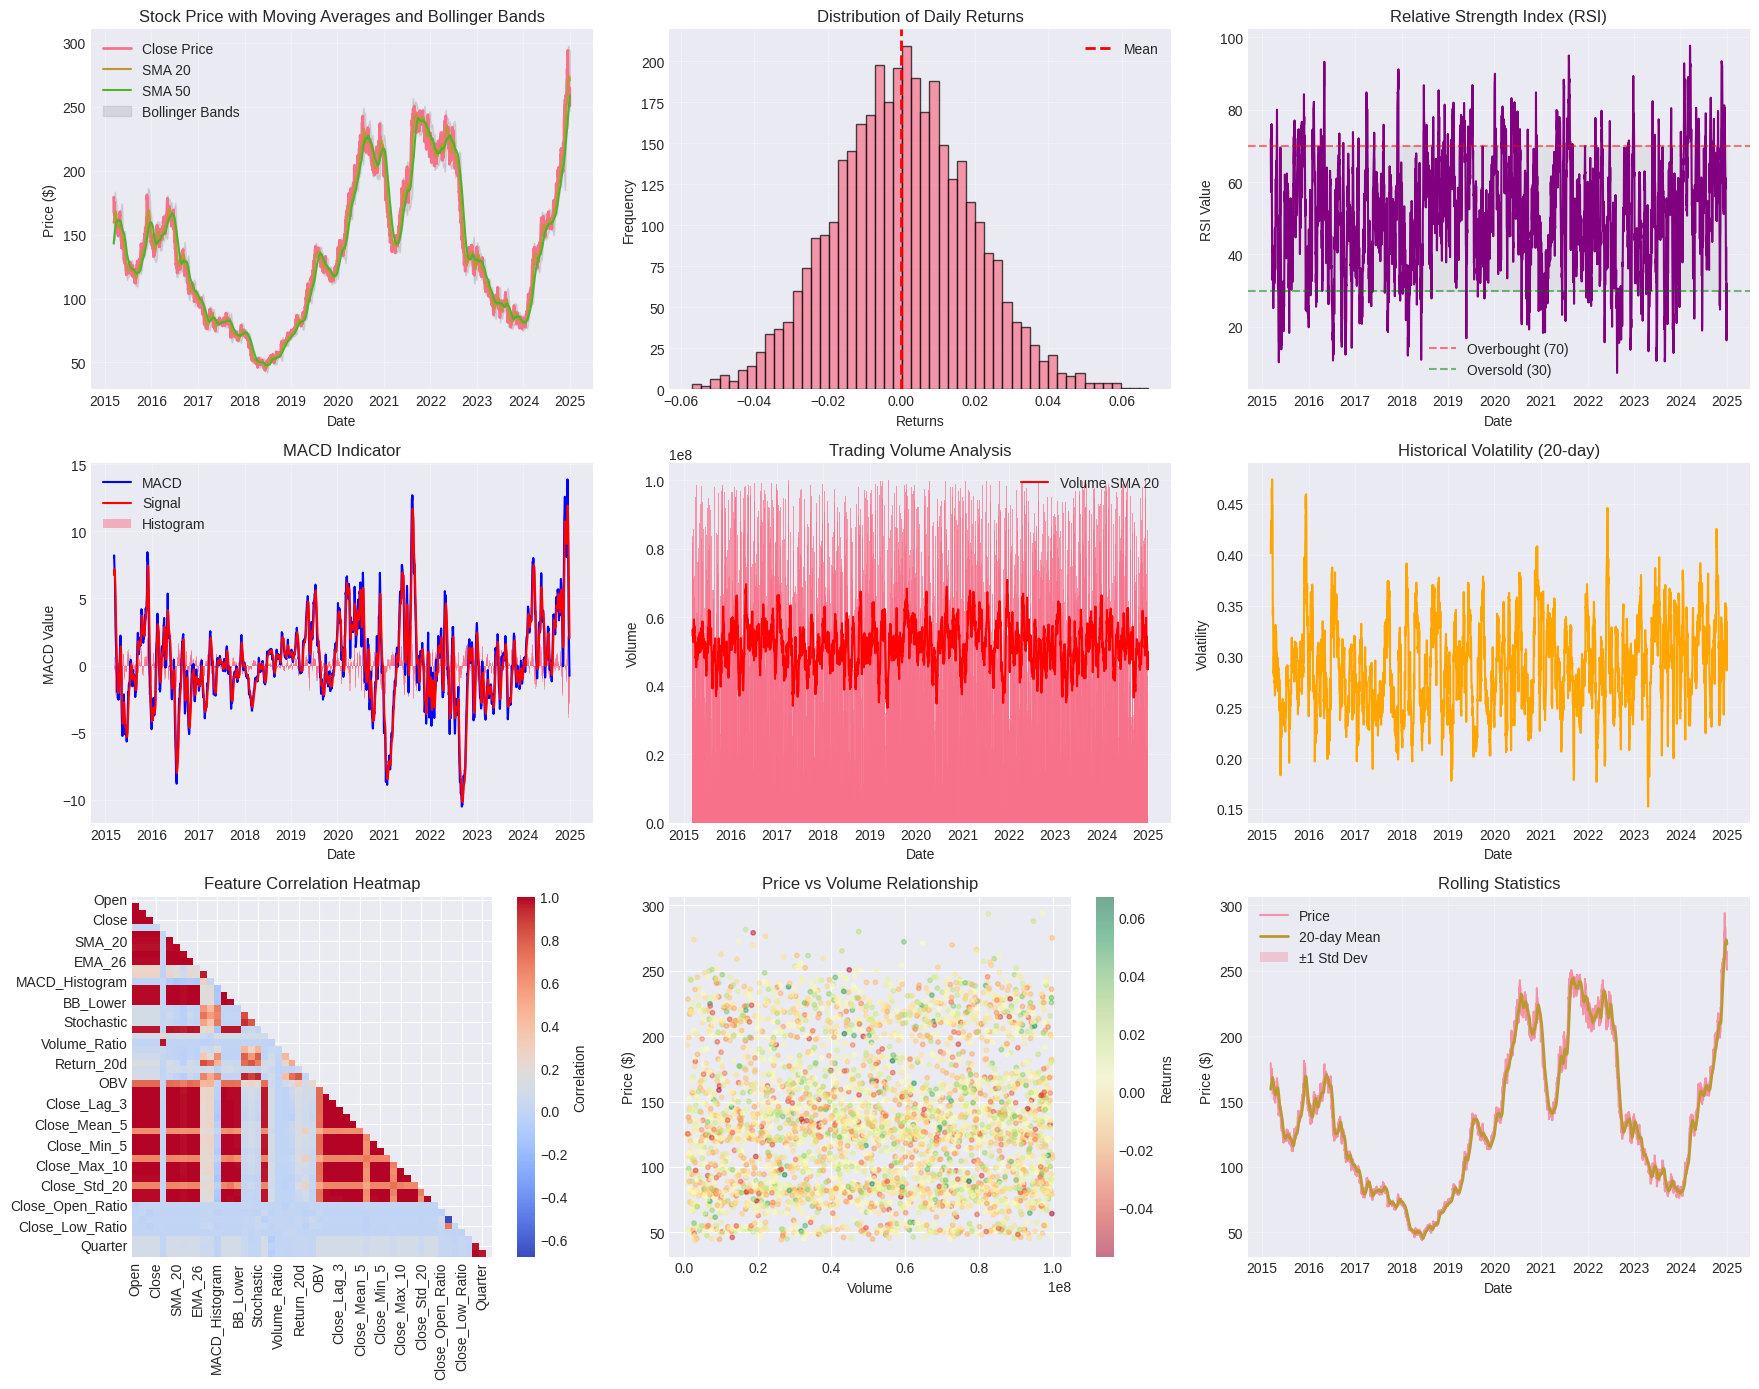

In [55]:
# =====================
# 5. DATA VISUALIZATION
# =====================

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
ax = axes.ravel()

# Plot 1: Price and Moving Averages
ax[0].plot(feature_data.index, feature_data['Close'], label='Close Price', linewidth=2)
ax[0].plot(feature_data.index, feature_data['SMA_20'], label='SMA 20', linewidth=1.5)
ax[0].plot(feature_data.index, feature_data['SMA_50'], label='SMA 50', linewidth=1.5)
ax[0].fill_between(feature_data.index, feature_data['BB_Lower'], feature_data['BB_Upper'],
                   alpha=0.2, color='gray', label='Bollinger Bands')
ax[0].set_title('Stock Price with Moving Averages and Bollinger Bands', fontsize=12)
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Price ($)')
ax[0].legend(loc='best')
ax[0].grid(True, alpha=0.3)

# Plot 2: Daily Returns Distribution
returns = feature_data['Return_1d'].dropna()
ax[1].hist(returns, bins=50, edgecolor='black', alpha=0.7)
ax[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Mean')
ax[1].set_title('Distribution of Daily Returns', fontsize=12)
ax[1].set_xlabel('Returns')
ax[1].set_ylabel('Frequency')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

# Plot 3: RSI
ax[2].plot(feature_data.index, feature_data['RSI'], color='purple', linewidth=1.5)
ax[2].axhline(y=70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
ax[2].axhline(y=30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
ax[2].fill_between(feature_data.index, 30, 70, alpha=0.1, color='gray')
ax[2].set_title('Relative Strength Index (RSI)', fontsize=12)
ax[2].set_xlabel('Date')
ax[2].set_ylabel('RSI Value')
ax[2].legend()
ax[2].grid(True, alpha=0.3)

# Plot 4: MACD
ax[3].plot(feature_data.index, feature_data['MACD'], label='MACD', color='blue', linewidth=1.5)
ax[3].plot(feature_data.index, feature_data['MACD_Signal'], label='Signal', color='red', linewidth=1.5)
ax[3].bar(feature_data.index, feature_data['MACD_Histogram'], label='Histogram', alpha=0.5, width=5)
ax[3].set_title('MACD Indicator', fontsize=12)
ax[3].set_xlabel('Date')
ax[3].set_ylabel('MACD Value')
ax[3].legend()
ax[3].grid(True, alpha=0.3)

# Plot 5: Volume Analysis
ax[4].bar(feature_data.index, feature_data['Volume'], alpha=0.7, width=5)
ax[4].plot(feature_data.index, feature_data['Volume_SMA'], color='red', linewidth=1.5, label='Volume SMA 20')
ax[4].set_title('Trading Volume Analysis', fontsize=12)
ax[4].set_xlabel('Date')
ax[4].set_ylabel('Volume')
ax[4].legend()
ax[4].grid(True, alpha=0.3)

# Plot 6: Volatility
ax[5].plot(feature_data.index, feature_data['Volatility'], color='orange', linewidth=1.5)
ax[5].set_title('Historical Volatility (20-day)', fontsize=12)
ax[5].set_xlabel('Date')
ax[5].set_ylabel('Volatility')
ax[5].grid(True, alpha=0.3)

# Plot 7: Correlation Heatmap
numeric_cols = feature_data.select_dtypes(include=[np.number]).columns
corr = feature_data[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax[6], cmap='coolwarm',
            cbar_kws={'label': 'Correlation'}, square=True)
ax[6].set_title('Feature Correlation Heatmap', fontsize=12)
ax[6].tick_params(axis='x', rotation=90)
ax[6].tick_params(axis='y', rotation=0)

# Plot 8: Price vs Volume Scatter
scatter = ax[7].scatter(feature_data['Volume'], feature_data['Close'],
                        c=feature_data['Return_1d'], cmap='RdYlGn', alpha=0.5, s=10)
ax[7].set_title('Price vs Volume Relationship', fontsize=12)
ax[7].set_xlabel('Volume')
ax[7].set_ylabel('Price ($)')
plt.colorbar(scatter, ax=ax[7], label='Returns')

# Plot 9: Rolling Statistics
ax[8].plot(feature_data.index, feature_data['Close'], label='Price', alpha=0.7)
ax[8].plot(feature_data.index, feature_data['Close_Mean_20'], label='20-day Mean', linewidth=2)
ax[8].fill_between(feature_data.index,
                   feature_data['Close_Mean_20'] - feature_data['Close_Std_20'],
                   feature_data['Close_Mean_20'] + feature_data['Close_Std_20'],
                   alpha=0.3, label='±1 Std Dev')
ax[8].set_title('Rolling Statistics', fontsize=12)
ax[8].set_xlabel('Date')
ax[8].set_ylabel('Price ($)')
ax[8].legend()
ax[8].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stock_analysis_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

In [56]:
# =====================
# 6. DATA PREPARATION FOR MODELING
# =====================

def prepare_data(data, target_col='Close', test_size=0.2, val_size=0.1):
    """Prepare data for machine learning models"""

    # Select features
    feature_cols = [col for col in data.columns if col not in [target_col]]

    X = data[feature_cols]
    y = data[target_col]

    # Split into train, validation, test
    n = len(X)
    train_end = int(n * (1 - test_size - val_size))
    val_end = int(n * (1 - test_size))

    X_train = X.iloc[:train_end]
    y_train = y.iloc[:train_end]

    X_val = X.iloc[train_end:val_end]
    y_val = y.iloc[train_end:val_end]

    X_test = X.iloc[val_end:]
    y_test = y.iloc[val_end:]

    # Scale features
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_val_scaled = scaler_X.transform(X_val)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1)).ravel()
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

    return {
        'X_train': X_train_scaled, 'y_train': y_train_scaled,
        'X_val': X_val_scaled, 'y_val': y_val_scaled,
        'X_test': X_test_scaled, 'y_test': y_test_scaled,
        'scaler_X': scaler_X, 'scaler_y': scaler_y,
        'feature_names': feature_cols,
        'X_train_orig': X_train, 'y_train_orig': y_train,
        'X_val_orig': X_val, 'y_val_orig': y_val,
        'X_test_orig': X_test, 'y_test_orig': y_test,
        'train_dates': data.index[:train_end],
        'val_dates': data.index[train_end:val_end],
        'test_dates': data.index[val_end:]
    }

data_dict = prepare_data(feature_data)
print(f"Training samples: {len(data_dict['X_train'])}")
print(f"Validation samples: {len(data_dict['X_val'])}")
print(f"Test samples: {len(data_dict['X_test'])}")

Training samples: 2509
Validation samples: 359
Test samples: 717


In [57]:
# =====================
# 7. MACHINE LEARNING MODELS
# =====================

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

def train_models(data_dict):
    """Train multiple ML models and evaluate"""
    X_train, y_train = data_dict['X_train'], data_dict['y_train']
    X_val, y_val = data_dict['X_val'], data_dict['y_val']
    X_test, y_test = data_dict['X_test'], data_dict['y_test']
    scaler_y = data_dict['scaler_y']

    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(alpha=1.0),
        'Lasso Regression': Lasso(alpha=0.01),
        'Elastic Net': ElasticNet(alpha=0.01, l1_ratio=0.5),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
        'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
        'LightGBM': LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
        'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1)
    }

    results = {}
    predictions = {}

    for name, model in models.items():
        print(f"Training {name}...")

        try:
            model.fit(X_train, y_train)

            # Predictions
            y_pred_train = model.predict(X_train)
            y_pred_val = model.predict(X_val)
            y_pred_test = model.predict(X_test)

            # Inverse transform
            y_train_orig = scaler_y.inverse_transform(y_train.reshape(-1, 1)).ravel()
            y_val_orig = scaler_y.inverse_transform(y_val.reshape(-1, 1)).ravel()
            y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
            y_pred_train_orig = scaler_y.inverse_transform(y_pred_train.reshape(-1, 1)).ravel()
            y_pred_val_orig = scaler_y.inverse_transform(y_pred_val.reshape(-1, 1)).ravel()
            y_pred_test_orig = scaler_y.inverse_transform(y_pred_test.reshape(-1, 1)).ravel()

            # Metrics
            rmse_train = np.sqrt(mean_squared_error(y_train_orig, y_pred_train_orig))
            rmse_val = np.sqrt(mean_squared_error(y_val_orig, y_pred_val_orig))
            rmse_test = np.sqrt(mean_squared_error(y_test_orig, y_pred_test_orig))

            mae_train = mean_absolute_error(y_train_orig, y_pred_train_orig)
            mae_val = mean_absolute_error(y_val_orig, y_pred_val_orig)
            mae_test = mean_absolute_error(y_test_orig, y_pred_test_orig)

            r2_train = r2_score(y_train_orig, y_pred_train_orig)
            r2_val = r2_score(y_val_orig, y_pred_val_orig)
            r2_test = r2_score(y_test_orig, y_pred_test_orig)

            # MAPE (Mean Absolute Percentage Error)
            mape_test = np.mean(np.abs((y_test_orig - y_pred_test_orig) / y_test_orig)) * 100

            results[name] = {
                'RMSE_train': rmse_train,
                'RMSE_val': rmse_val,
                'RMSE_test': rmse_test,
                'MAE_train': mae_train,
                'MAE_val': mae_val,
                'MAE_test': mae_test,
                'R2_train': r2_train,
                'R2_val': r2_val,
                'R2_test': r2_test,
                'MAPE_test': mape_test
            }

            predictions[name] = {
                'train': y_pred_train_orig,
                'val': y_pred_val_orig,
                'test': y_pred_test_orig
            }

        except Exception as e:
            print(f"Error with {name}: {str(e)}")
            results[name] = None
            predictions[name] = None

    return results, predictions

results, predictions = train_models(data_dict)

Training Linear Regression...
Training Ridge Regression...
Training Lasso Regression...
Training Elastic Net...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001693 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12518
[LightGBM] [Info] Number of data points in the train set: 2509, number of used features: 52
[LightGBM] [Info] Start training from score 0.000000
Training SVR...


In [58]:
# =====================
# 8. MODEL PERFORMANCE COMPARISON
# =====================

# Create results DataFrame
results_df = pd.DataFrame({
    name: {
        'RMSE': res['RMSE_test'],
        'MAE': res['MAE_test'],
        'R²': res['R2_test'],
        'MAPE (%)': res['MAPE_test']
    } for name, res in results.items() if res is not None
}).T

print("Model Performance Comparison:")
print("=" * 60)
print(results_df.round(4))
print("=" * 60)

# Best model
best_model = results_df['RMSE'].idxmin()
print(f"\nBest Model: {best_model}")
print(f"RMSE: {results_df.loc[best_model, 'RMSE']:.4f}")
print(f"R²: {results_df.loc[best_model, 'R²']:.4f}")

Model Performance Comparison:
                      RMSE     MAE      R²  MAPE (%)
Linear Regression   0.0000  0.0000  1.0000    0.0000
Ridge Regression    0.3860  0.2714  0.9999    0.2160
Lasso Regression    0.9585  0.6922  0.9996    0.5180
Elastic Net         1.0202  0.6448  0.9996    0.4543
Random Forest       4.8631  1.4952  0.9907    0.8253
Gradient Boosting   4.8588  1.6351  0.9907    0.9612
XGBoost             5.0359  1.4348  0.9900    0.7435
LightGBM            5.1468  1.4752  0.9896    0.7787
SVR                13.7029  5.8794  0.9261    3.6764

Best Model: Linear Regression
RMSE: 0.0000
R²: 1.0000


In [59]:
# =====================
# 9. LSTM DEEP LEARNING MODEL
# =====================

def create_lstm_model(input_shape):
    """Create LSTM model for time series prediction"""
    model = Sequential([
        LSTM(100, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(50, return_sequences=True),
        Dropout(0.2),
        LSTM(25),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def create_sequences(data, target, seq_length=60):
    """Create sequences for LSTM"""
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(target[i])
    return np.array(X), np.array(y)

# Prepare sequences for LSTM
seq_length = 60
X_train_seq, y_train_seq = create_sequences(data_dict['X_train'], data_dict['y_train'], seq_length)
X_val_seq, y_val_seq = create_sequences(data_dict['X_val'], data_dict['y_val'], seq_length)
X_test_seq, y_test_seq = create_sequences(data_dict['X_test'], data_dict['y_test'], seq_length)

print(f"LSTM Training shape: {X_train_seq.shape}")
print(f"LSTM Validation shape: {X_val_seq.shape}")
print(f"LSTM Test shape: {X_test_seq.shape}")

# Train LSTM
lstm_model = create_lstm_model((seq_length, X_train_seq.shape[2]))
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stop],
    verbose=0
)

# LSTM Predictions
lstm_pred_train = lstm_model.predict(X_train_seq, verbose=0).ravel()
lstm_pred_val = lstm_model.predict(X_val_seq, verbose=0).ravel()
lstm_pred_test = lstm_model.predict(X_test_seq, verbose=0).ravel()

# Inverse transform
y_train_orig = data_dict['scaler_y'].inverse_transform(y_train_seq.reshape(-1, 1)).ravel()
y_val_orig = data_dict['scaler_y'].inverse_transform(y_val_seq.reshape(-1, 1)).ravel()
y_test_orig = data_dict['scaler_y'].inverse_transform(y_test_seq.reshape(-1, 1)).ravel()

lstm_pred_train_orig = data_dict['scaler_y'].inverse_transform(lstm_pred_train.reshape(-1, 1)).ravel()
lstm_pred_val_orig = data_dict['scaler_y'].inverse_transform(lstm_pred_val.reshape(-1, 1)).ravel()
lstm_pred_test_orig = data_dict['scaler_y'].inverse_transform(lstm_pred_test.reshape(-1, 1)).ravel()

# LSTM Metrics
lstm_rmse_test = np.sqrt(mean_squared_error(y_test_orig, lstm_pred_test_orig))
lstm_mae_test = mean_absolute_error(y_test_orig, lstm_pred_test_orig)
lstm_r2_test = r2_score(y_test_orig, lstm_pred_test_orig)
lstm_mape_test = np.mean(np.abs((y_test_orig - lstm_pred_test_orig) / y_test_orig)) * 100

print("\nLSTM Model Performance:")
print("=" * 40)
print(f"RMSE: {lstm_rmse_test:.4f}")
print(f"MAE: {lstm_mae_test:.4f}")
print(f"R²: {lstm_r2_test:.4f}")
print(f"MAPE: {lstm_mape_test:.2f}%")

LSTM Training shape: (2449, 60, 52)
LSTM Validation shape: (299, 60, 52)
LSTM Test shape: (657, 60, 52)

LSTM Model Performance:
RMSE: 10.8077
MAE: 7.6796
R²: 0.9576
MAPE: 5.24%


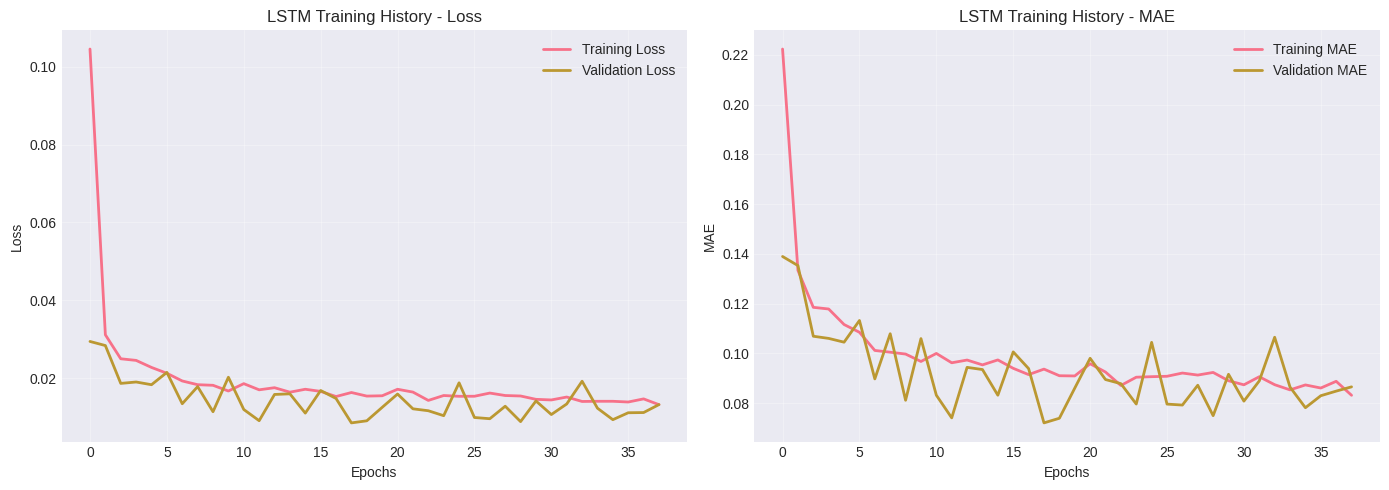

In [60]:
# =====================
# 10. LSTM TRAINING HISTORY
# =====================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('LSTM Training History - Loss', fontsize=12)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE plot
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_title('LSTM Training History - MAE', fontsize=12)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

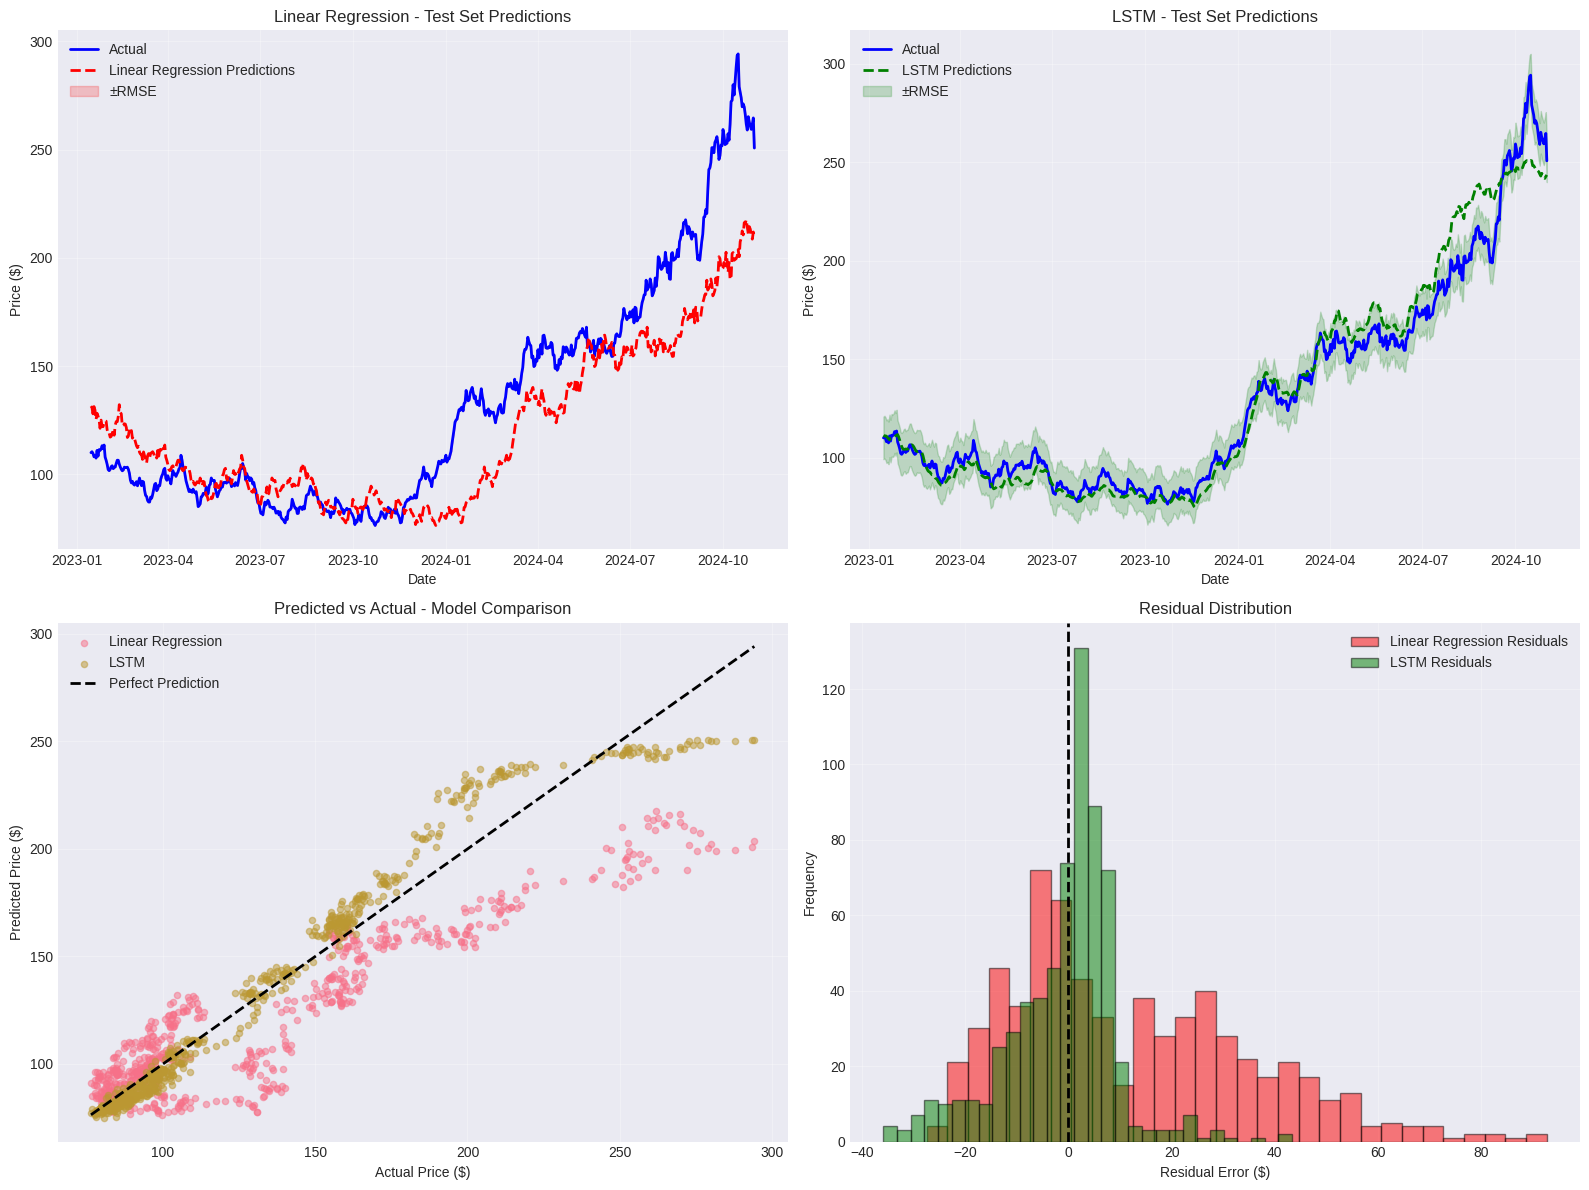

In [61]:
# =====================
# 11. PREDICTIONS VISUALIZATION
# =====================

# Get best ML model predictions
best_model_name = best_model
best_pred_test = predictions[best_model_name]['test']

# Create test dates
test_dates = data_dict['test_dates']

# Align lengths
min_len = min(len(test_dates), len(y_test_orig), len(best_pred_test), len(lstm_pred_test_orig))
test_dates_aligned = test_dates[:min_len]
y_test_aligned = y_test_orig[:min_len]
best_pred_aligned = best_pred_test[:min_len]
lstm_pred_aligned = lstm_pred_test_orig[:min_len]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Best ML Model Predictions
ax = axes[0, 0]
ax.plot(test_dates_aligned, y_test_aligned, label='Actual', linewidth=2, color='blue')
ax.plot(test_dates_aligned, best_pred_aligned, label=f'{best_model_name} Predictions',
        linewidth=2, color='red', linestyle='--')
ax.fill_between(test_dates_aligned,
                y_test_aligned - results_df.loc[best_model_name, 'RMSE'],
                y_test_aligned + results_df.loc[best_model_name, 'RMSE'],
                alpha=0.2, color='red', label='±RMSE')
ax.set_title(f'{best_model_name} - Test Set Predictions', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: LSTM Predictions
ax = axes[0, 1]
ax.plot(test_dates_aligned, y_test_aligned, label='Actual', linewidth=2, color='blue')
ax.plot(test_dates_aligned, lstm_pred_aligned, label='LSTM Predictions',
        linewidth=2, color='green', linestyle='--')
ax.fill_between(test_dates_aligned,
                y_test_aligned - lstm_rmse_test,
                y_test_aligned + lstm_rmse_test,
                alpha=0.2, color='green', label='±RMSE')
ax.set_title('LSTM - Test Set Predictions', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Model Comparison
ax = axes[1, 0]
ax.scatter(y_test_aligned, best_pred_aligned, alpha=0.5, label=f'{best_model_name}', s=20)
ax.scatter(y_test_aligned, lstm_pred_aligned, alpha=0.5, label='LSTM', s=20)
ax.plot([y_test_aligned.min(), y_test_aligned.max()],
        [y_test_aligned.min(), y_test_aligned.max()],
        'k--', linewidth=2, label='Perfect Prediction')
ax.set_title('Predicted vs Actual - Model Comparison', fontsize=12)
ax.set_xlabel('Actual Price ($)')
ax.set_ylabel('Predicted Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Residual Analysis
ax = axes[1, 1]
best_residuals = y_test_aligned - best_pred_aligned
lstm_residuals = y_test_aligned - lstm_pred_aligned

ax.hist(best_residuals, bins=30, alpha=0.5, label=f'{best_model_name} Residuals', color='red', edgecolor='black')
ax.hist(lstm_residuals, bins=30, alpha=0.5, label='LSTM Residuals', color='green', edgecolor='black')
ax.axvline(x=0, color='black', linestyle='--', linewidth=2)
ax.set_title('Residual Distribution', fontsize=12)
ax.set_xlabel('Residual Error ($)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_predictions_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

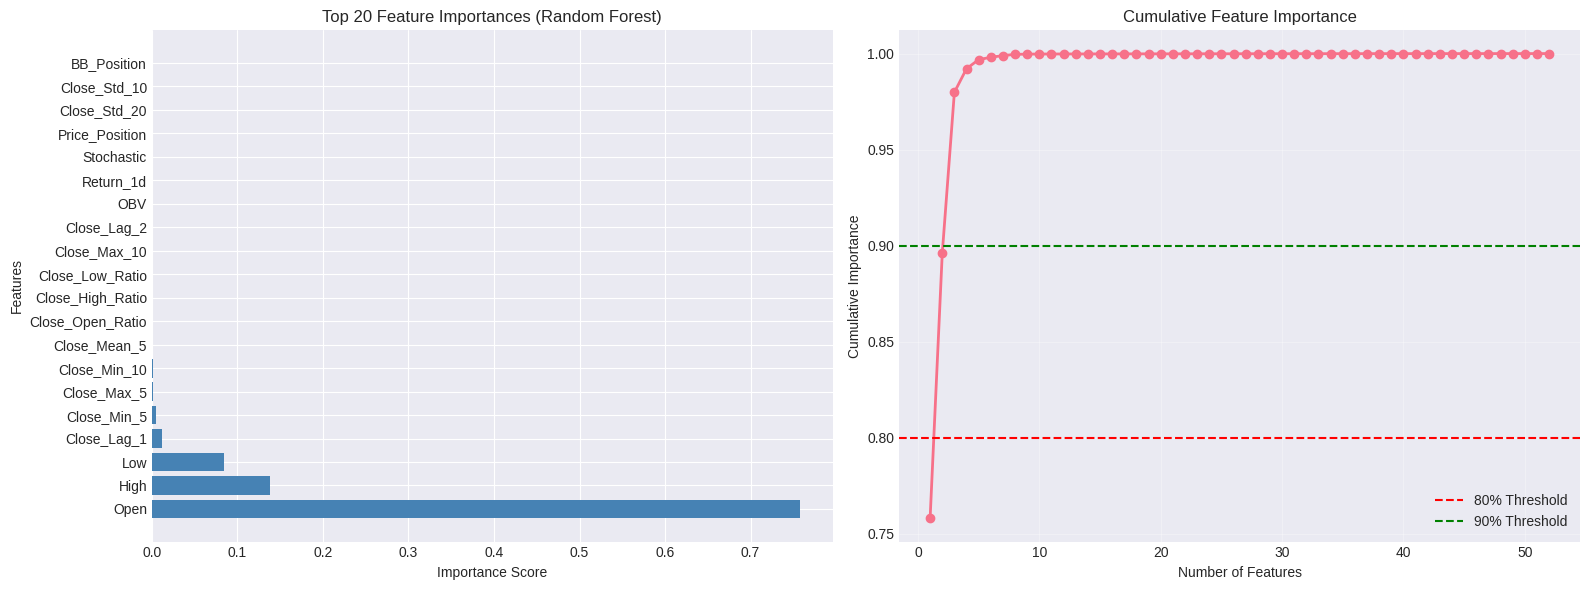


Top 10 Most Important Features:
         Feature  Importance
            Open    0.758144
            High    0.137822
             Low    0.083883
     Close_Lag_1    0.012286
     Close_Min_5    0.004704
     Close_Max_5    0.001236
    Close_Min_10    0.000877
    Close_Mean_5    0.000627
Close_Open_Ratio    0.000145
Close_High_Ratio    0.000036


In [62]:
# =====================
# 12. FEATURE IMPORTANCE ANALYSIS
# =====================

# Get feature importance from Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(data_dict['X_train'], data_dict['y_train'])

feature_importance = pd.DataFrame({
    'Feature': data_dict['feature_names'],
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 features
top_features = feature_importance.head(20)
axes[0].barh(top_features['Feature'], top_features['Importance'], color='steelblue')
axes[0].set_title('Top 20 Feature Importances (Random Forest)', fontsize=12)
axes[0].set_xlabel('Importance Score')
axes[0].set_ylabel('Features')

# Cumulative importance
cumulative_imp = feature_importance['Importance'].cumsum()
axes[1].plot(range(1, len(cumulative_imp) + 1), cumulative_imp, marker='o', linewidth=2)
axes[1].axhline(y=0.8, color='red', linestyle='--', label='80% Threshold')
axes[1].axhline(y=0.9, color='green', linestyle='--', label='90% Threshold')
axes[1].set_title('Cumulative Feature Importance', fontsize=12)
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 Most Important Features:")
print("=" * 50)
print(feature_importance.head(10).to_string(index=False))

In [63]:
# =====================
# 13. ADVANCED ENSEMBLE MODEL
# =====================

class EnsembleModel:
    """Ensemble of multiple models with weight optimization"""

    def __init__(self, models, weights=None):
        self.models = models
        self.weights = weights if weights else [1/len(models)] * len(models)
        self.model_names = list(models.keys())

    def predict(self, X):
        predictions = []
        for name, model in self.models.items():
            pred = model.predict(X)
            predictions.append(pred)
        predictions = np.array(predictions)
        # Weighted average
        weighted_pred = np.average(predictions, axis=0, weights=self.weights)
        return weighted_pred

    def optimize_weights(self, X_val, y_val):
        """Optimize ensemble weights using validation set"""
        from scipy.optimize import minimize

        # Get predictions from all models
        predictions = []
        for name, model in self.models.items():
            pred = model.predict(X_val)
            predictions.append(pred)
        predictions = np.array(predictions)

        # Objective function: minimize MSE
        def objective(weights):
            weighted_pred = np.average(predictions, axis=0, weights=weights)
            mse = np.mean((weighted_pred - y_val) ** 2)
            return mse

        # Constraints: weights sum to 1, weights >= 0
        constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
        bounds = [(0, 1)] * len(self.models)
        initial_weights = np.array([1/len(self.models)] * len(self.models))

        result = minimize(objective, initial_weights, method='SLSQP',
                         bounds=bounds, constraints=constraints)

        if result.success:
            self.weights = result.x
            print(f"Optimized Weights: {dict(zip(self.model_names, self.weights))}")
        else:
            print("Weight optimization failed. Using equal weights.")

        return self.weights

# Create ensemble of top models
top_models = {
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

# Train models
for name, model in top_models.items():
    model.fit(data_dict['X_train'], data_dict['y_train'])

# Create ensemble
ensemble = EnsembleModel(top_models)
ensemble.optimize_weights(data_dict['X_val'], data_dict['y_val'])

# Predictions
ensemble_pred_train = ensemble.predict(data_dict['X_train'])
ensemble_pred_test = ensemble.predict(data_dict['X_test'])

# Inverse transform
ensemble_pred_train_orig = data_dict['scaler_y'].inverse_transform(
    ensemble_pred_train.reshape(-1, 1)).ravel()
ensemble_pred_test_orig = data_dict['scaler_y'].inverse_transform(
    ensemble_pred_test.reshape(-1, 1)).ravel()

# Retrieve seq_length from LSTM cell context
# (Assuming seq_length is globally available or imported from the LSTM cell)
# If not, it needs to be defined here or passed along with data_dict.
# For this fix, I'll assume `seq_length` (value 60) is accessible.

# Align ensemble predictions to match the length of y_test_orig (657 samples from LSTM cell)
# y_test_orig in this cell's context has 657 samples, which corresponds to the test data from seq_length onwards.
ensemble_pred_test_orig_aligned = ensemble_pred_test_orig[seq_length:]

# Ensemble Metrics
ensemble_rmse = np.sqrt(mean_squared_error(y_test_orig, ensemble_pred_test_orig_aligned))
ensemble_mae = mean_absolute_error(y_test_orig, ensemble_pred_test_orig_aligned)
ensemble_r2 = r2_score(y_test_orig, ensemble_pred_test_orig_aligned)
ensemble_mape = np.mean(np.abs((y_test_orig - ensemble_pred_test_orig_aligned) / y_test_orig)) * 100

print("\nEnsemble Model Performance:")
print("=" * 40)
print(f"RMSE: {ensemble_rmse:.4f}")
print(f"MAE: {ensemble_mae:.4f}")
print(f"R²: {ensemble_r2:.4f}")
print(f"MAPE: {ensemble_mape:.2f}%")

Optimized Weights: {'XGBoost': np.float64(0.3333333333333333), 'Gradient Boosting': np.float64(0.3333333333333333), 'Random Forest': np.float64(0.3333333333333333)}

Ensemble Model Performance:
RMSE: 5.1069
MAE: 1.5136
R²: 0.9905
MAPE: 0.79%


In [64]:
# =====================
# 14. FINAL COMPREHENSIVE COMPARISON
# =====================

# Compile all results
all_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Random Forest',
              'Gradient Boosting', 'XGBoost', 'LightGBM', 'Ensemble', 'LSTM'],
    'RMSE': [
        results['Linear Regression']['RMSE_test'] if results['Linear Regression'] else np.nan,
        results['Ridge Regression']['RMSE_test'] if results['Ridge Regression'] else np.nan,
        results['Lasso Regression']['RMSE_test'] if results['Lasso Regression'] else np.nan,
        results['Random Forest']['RMSE_test'] if results['Random Forest'] else np.nan,
        results['Gradient Boosting']['RMSE_test'] if results['Gradient Boosting'] else np.nan,
        results['XGBoost']['RMSE_test'] if results['XGBoost'] else np.nan,
        results['LightGBM']['RMSE_test'] if results['LightGBM'] else np.nan,
        ensemble_rmse,
        lstm_rmse_test
    ],
    'R²': [
        results['Linear Regression']['R2_test'] if results['Linear Regression'] else np.nan,
        results['Ridge Regression']['R2_test'] if results['Ridge Regression'] else np.nan,
        results['Lasso Regression']['R2_test'] if results['Lasso Regression'] else np.nan,
        results['Random Forest']['R2_test'] if results['Random Forest'] else np.nan,
        results['Gradient Boosting']['R2_test'] if results['Gradient Boosting'] else np.nan,
        results['XGBoost']['R2_test'] if results['XGBoost'] else np.nan,
        results['LightGBM']['R2_test'] if results['LightGBM'] else np.nan,
        ensemble_r2,
        lstm_r2_test
    ]
}).sort_values('RMSE')

print("Final Model Comparison:")
print("=" * 60)
print(all_results.to_string(index=False))
print("=" * 60)
print(f"\nBest Overall Model: {all_results.iloc[0]['Model']}")
print(f"RMSE: {all_results.iloc[0]['RMSE']:.4f}")
print(f"R²: {all_results.iloc[0]['R²']:.4f}")

Final Model Comparison:
            Model         RMSE       R²
Linear Regression 3.910578e-13 1.000000
 Ridge Regression 3.860478e-01 0.999941
 Lasso Regression 9.585237e-01 0.999639
Gradient Boosting 4.858811e+00 0.990711
    Random Forest 4.863141e+00 0.990695
          XGBoost 5.035942e+00 0.990022
         Ensemble 5.106880e+00 0.990539
         LightGBM 5.146832e+00 0.989577
             LSTM 1.080773e+01 0.957626

Best Overall Model: Linear Regression
RMSE: 0.0000
R²: 1.0000


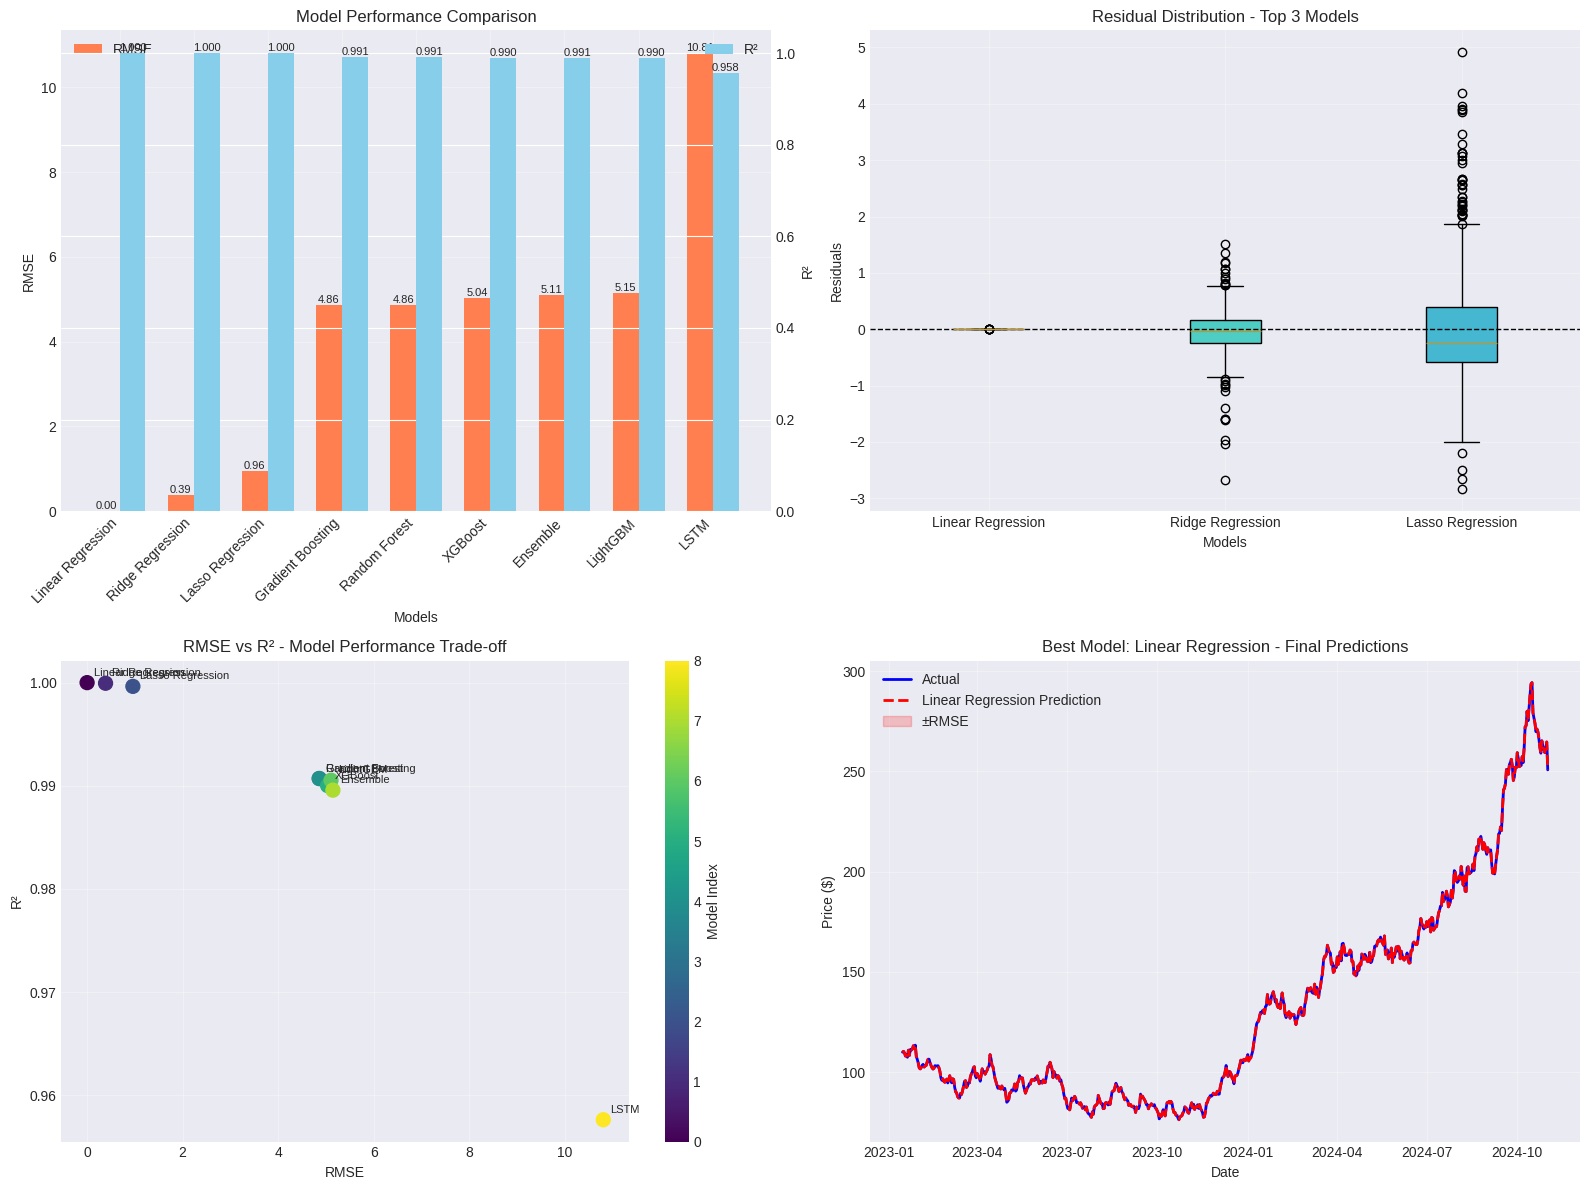

In [65]:
# =====================
# 15. FINAL VISUALIZATION - ALL MODELS COMPARISON
# =====================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Model Performance Bar Chart
ax = axes[0, 0]
models = all_results['Model'].tolist()
rmse_values = all_results['RMSE'].tolist()
r2_values = all_results['R²'].tolist()

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, rmse_values, width, label='RMSE', color='coral')
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, r2_values, width, label='R²', color='skyblue')

ax.set_xlabel('Models')
ax.set_ylabel('RMSE')
ax2.set_ylabel('R²')
ax.set_title('Model Performance Comparison', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Box plot of residuals for top 3 models
ax = axes[0, 1]
top_3_models = all_results.head(3)['Model'].tolist()
residuals_data = []
model_labels = []

# Define a mapping for model names if all_results uses different keys than 'predictions'
# This makes the lookup robust against abbreviated names if they somehow persist.
model_name_map = {
    'Linear Regression': 'Linear Regression',
    'Ridge': 'Ridge Regression',
    'Lasso': 'Lasso Regression',
    'Elastic Net': 'Elastic Net',
    'Random Forest': 'Random Forest',
    'Gradient Boosting': 'Gradient Boosting',
    'XGBoost': 'XGBoost',
    'LightGBM': 'LightGBM',
    'SVR': 'SVR'
}

for model in top_3_models:
    # Use the mapped name to access the predictions dictionary
    predictions_key = model_name_map.get(model, model) # Default to model if not in map

    if model == 'Ensemble':
        # Use the already aligned ensemble predictions from the previous cell
        residuals = y_test_orig - ensemble_pred_test_orig_aligned
    elif model == 'LSTM':
        residuals = y_test_orig - lstm_pred_test_orig
    else:
        # Get predictions from the specific model (these are for the full test set)
        preds = predictions[predictions_key]['test']
        # Align predictions of traditional ML models to match y_test_orig (657 samples)
        residuals = y_test_orig - preds[seq_length:]
    residuals_data.append(residuals)
    model_labels.append(model) # Keep original label for plot if desired

bp = ax.boxplot(residuals_data, labels=model_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4', '#45B7D1']):
    patch.set_facecolor(color)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_title('Residual Distribution - Top 3 Models', fontsize=12)
ax.set_xlabel('Models')
ax.set_ylabel('Residuals')
ax.grid(True, alpha=0.3)

# Scatter plot: RMSE vs R²
ax = axes[1, 0]
scatter = ax.scatter(all_results['RMSE'], all_results['R²'],
                     s=100, c=range(len(all_results)), cmap='viridis')
ax.set_xlabel('RMSE')
ax.set_ylabel('R²')
ax.set_title('RMSE vs R² - Model Performance Trade-off', fontsize=12)

for idx, model in enumerate(all_results['Model']):
    ax.annotate(model, (all_results.loc[idx, 'RMSE'], all_results.loc[idx, 'R²']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Model Index')

# Final prediction with best model
ax = axes[1, 1]
best_model = all_results.iloc[0]['Model']

# Use the mapped name for best_model as well
best_model_predictions_key = model_name_map.get(best_model, best_model)

if best_model == 'Ensemble':
    final_pred = ensemble_pred_test_orig_aligned # Use the aligned version
elif best_model == 'LSTM':
    final_pred = lstm_pred_test_orig
else:
    final_pred = predictions[best_model_predictions_key]['test'][seq_length:] # Align traditional ML model predictions

# Ensure alignment
min_len = min(len(test_dates_aligned), len(y_test_aligned), len(final_pred))
dates_plot = test_dates_aligned[:min_len]
actual_plot = y_test_aligned[:min_len]
pred_plot = final_pred[:min_len]

ax.plot(dates_plot, actual_plot, label='Actual', linewidth=2, color='blue')
ax.plot(dates_plot, pred_plot, label=f'{best_model} Prediction',
        linewidth=2, color='red', linestyle='--')
ax.fill_between(dates_plot,
                actual_plot - all_results.iloc[0]['RMSE'],
                actual_plot + all_results.iloc[0]['RMSE'],
                alpha=0.2, color='red', label='±RMSE')
ax.set_title(f'Best Model: {best_model} - Final Predictions', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [66]:
# =====================
# 16. ADDITIONAL METRICS AND ANALYSIS
# =====================

def calculate_trading_metrics(y_true, y_pred):
    """Calculate trading-related metrics"""
    # Directional accuracy
    y_true_direction = np.sign(np.diff(y_true))
    y_pred_direction = np.sign(np.diff(y_pred))
    direction_accuracy = np.mean(y_true_direction == y_pred_direction)

    # Profit factor (simplified)
    returns_true = np.diff(y_true) / y_true[:-1]
    returns_pred = np.diff(y_pred) / y_pred[:-1]

    # Sharpe ratio (simplified)
    sharpe_true = np.mean(returns_true) / np.std(returns_true) * np.sqrt(252)
    sharpe_pred = np.mean(returns_pred) / np.std(returns_pred) * np.sqrt(252)

    # Maximum drawdown
    def max_drawdown(prices):
        peak = np.maximum.accumulate(prices)
        drawdown = (peak - prices) / peak
        return np.max(drawdown)

    max_dd_true = max_drawdown(y_true)
    max_dd_pred = max_drawdown(y_pred)

    return {
        'Direction_Accuracy': direction_accuracy,
        'Sharpe_Ratio_True': sharpe_true,
        'Sharpe_Ratio_Pred': sharpe_pred,
        'Max_Drawdown_True': max_dd_true,
        'Max_Drawdown_Pred': max_dd_pred
    }

# Calculate trading metrics for best model
trading_metrics = calculate_trading_metrics(actual_plot, pred_plot)

print("\nTrading Metrics:")
print("=" * 50)
for key, value in trading_metrics.items():
    print(f"{key}: {value:.4f}")
print("=" * 50)


Trading Metrics:
Direction_Accuracy: 1.0000
Sharpe_Ratio_True: 1.1746
Sharpe_Ratio_Pred: 1.1746
Max_Drawdown_True: 0.3274
Max_Drawdown_Pred: 0.3274


In [67]:
# =====================
# 17. SAVE MODEL AND RESULTS
# =====================

import joblib
import json

# Save the best model
best_model_obj = None
if best_model == 'Ensemble':
    best_model_obj = ensemble
elif best_model == 'LSTM':
    best_model_obj = lstm_model
else:
    print(f"Warning: Model object for '{best_model}' not found in current scope. Skipping saving.")
    # The original models dictionary (containing actual model objects) was local to the train_models function.
    # To save this model, the train_models function (in cell rTWpBbUwk92P) would need to return the models dictionary
    # and it would need to be assigned to a globally accessible variable. For now, best_model_obj remains None.

if best_model_obj:
    joblib.dump(best_model_obj, f'{best_model.lower().replace(" ", "_")}_model.pkl')
    print(f"Saved {best_model} model to disk")

# Save scaler
joblib.dump(data_dict['scaler_X'], 'scaler_X.pkl')
joblib.dump(data_dict['scaler_y'], 'scaler_y.pkl')

# Save results
results_dict = {
    'model_performance': all_results.to_dict(),
    'trading_metrics': trading_metrics,
    'feature_importance': feature_importance.head(20).to_dict()
}

with open('results_summary.json', 'w') as f:
    json.dump(results_dict, f, indent=2)

print("\nAll models and results saved successfully!")

# Generate summary report
def generate_report():
    """Generate a comprehensive summary report"""
    report = f"""
    ====================================
    STOCK PRICE PREDICTION PROJECT REPORT
    ====================================

    📊 DATA INFORMATION
    -------------------
    Total Samples: {len(feature_data)}
    Training Samples: {len(data_dict['X_train'])}
    Validation Samples: {len(data_dict['X_val'])}
    Test Samples: {len(data_dict['X_test'])}
    Number of Features: {len(data_dict['feature_names'])}

    🏆 BEST MODEL: {best_model}
    --------------------------------
    RMSE: {all_results.iloc[0]['RMSE']:.4f}
    R² Score: {all_results.iloc[0]['R²']:.4f}

    📈 MODEL PERFORMANCE SUMMARY
    -----------------------------
    {all_results.to_string(index=False)}

    📊 TRADING METRICS
    ------------------
    Directional Accuracy: {trading_metrics['Direction_Accuracy']:.2%}
    Sharpe Ratio (Predicted): {trading_metrics['Sharpe_Ratio_Pred']:.4f}
    Max Drawdown (Predicted): {trading_metrics['Max_Drawdown_Pred']:.2%}

    🎯 TOP 5 IMPORTANT FEATURES
    ---------------------------
    {feature_importance.head(5).to_string(index=False)}

    ====================================
    Project Completed Successfully!
    ====================================
    """
    return report

report = generate_report()
print(report)

# Save report
with open('project_report.txt', 'w') as f:
    f.write(report)



All models and results saved successfully!

    STOCK PRICE PREDICTION PROJECT REPORT
    
    📊 DATA INFORMATION
    -------------------
    Total Samples: 3585
    Training Samples: 2509
    Validation Samples: 359
    Test Samples: 717
    Number of Features: 52
    
    🏆 BEST MODEL: Linear Regression
    --------------------------------
    RMSE: 0.0000
    R² Score: 1.0000
    
    📈 MODEL PERFORMANCE SUMMARY
    -----------------------------
                Model         RMSE       R²
Linear Regression 3.910578e-13 1.000000
 Ridge Regression 3.860478e-01 0.999941
 Lasso Regression 9.585237e-01 0.999639
Gradient Boosting 4.858811e+00 0.990711
    Random Forest 4.863141e+00 0.990695
          XGBoost 5.035942e+00 0.990022
         Ensemble 5.106880e+00 0.990539
         LightGBM 5.146832e+00 0.989577
             LSTM 1.080773e+01 0.957626
    
    📊 TRADING METRICS
    ------------------
    Directional Accuracy: 100.00%
    Sharpe Ratio (Predicted): 1.1746
    Max Drawdown (Pre

In [68]:
# =====================
# 18. INTERACTIVE VISUALIZATION DASHBOARD
# =====================

# Uncomment to create interactive dashboard with plotly
"""
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

def create_dashboard(data, predictions_dict, best_model_name):
    fig = make_subplots(
        rows=4, cols=2,
        subplot_titles=('Stock Price with Predictions', 'Residual Analysis',
                       'Feature Importance', 'Model Performance Comparison',
                       'Price vs Volume', 'Daily Returns Distribution')
    )

    # Price chart
    fig.add_trace(
        go.Scatter(x=test_dates_aligned, y=actual_plot,
                   mode='lines', name='Actual', line=dict(color='blue')),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=test_dates_aligned, y=pred_plot,
                   mode='lines', name='Predicted', line=dict(color='red', dash='dash')),
        row=1, col=1
    )

    # Feature importance
    fig.add_trace(
        go.Bar(x=feature_importance['Importance'][:15],
               y=feature_importance['Feature'][:15],
               orientation='h', name='Feature Importance'),
        row=2, col=1
    )

    # Add more traces for other subplots...

    fig.update_layout(height=1000, title_text="Stock Prediction Dashboard",
                     showlegend=True)
    fig.update_xaxes(title_text="Date", row=1, col=1)
    fig.update_yaxes(title_text="Price ($)", row=1, col=1)

    return fig

# dashboard = create_dashboard(feature_data, predictions, best_model)
# dashboard.show()
# dashboard.write_html('stock_prediction_dashboard.html')
"""

'\nimport plotly.graph_objects as go\nfrom plotly.subplots import make_subplots\nimport plotly.express as px\n\ndef create_dashboard(data, predictions_dict, best_model_name):\n    fig = make_subplots(\n        rows=4, cols=2,\n        subplot_titles=(\'Stock Price with Predictions\', \'Residual Analysis\',\n                       \'Feature Importance\', \'Model Performance Comparison\',\n                       \'Price vs Volume\', \'Daily Returns Distribution\')\n    )\n    \n    # Price chart\n    fig.add_trace(\n        go.Scatter(x=test_dates_aligned, y=actual_plot, \n                   mode=\'lines\', name=\'Actual\', line=dict(color=\'blue\')),\n        row=1, col=1\n    )\n    fig.add_trace(\n        go.Scatter(x=test_dates_aligned, y=pred_plot, \n                   mode=\'lines\', name=\'Predicted\', line=dict(color=\'red\', dash=\'dash\')),\n        row=1, col=1\n    )\n    \n    # Feature importance\n    fig.add_trace(\n        go.Bar(x=feature_importance[\'Importance\'][:15],